<a href="https://colab.research.google.com/github/tagian/Amazon-Insight-Engine/blob/main/AmazonInsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wordcloud matplotlib


In [ ]:
!pip install datasets


In [ ]:
!pip install --upgrade datasets

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

Gift_Cards.jsonl:   0%|          | 0.00/50.2M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

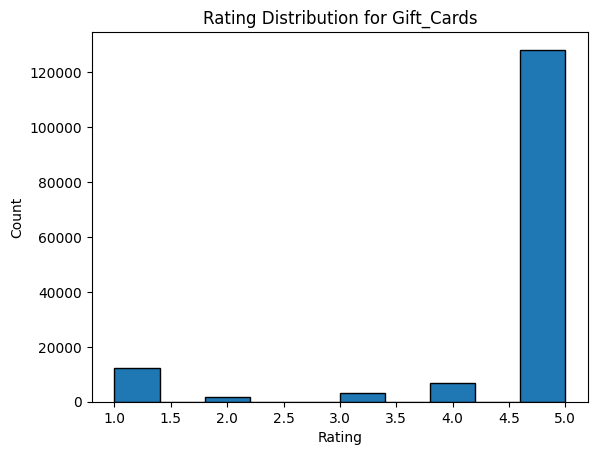

Magazine_Subscriptions.jsonl:   0%|          | 0.00/33.3M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

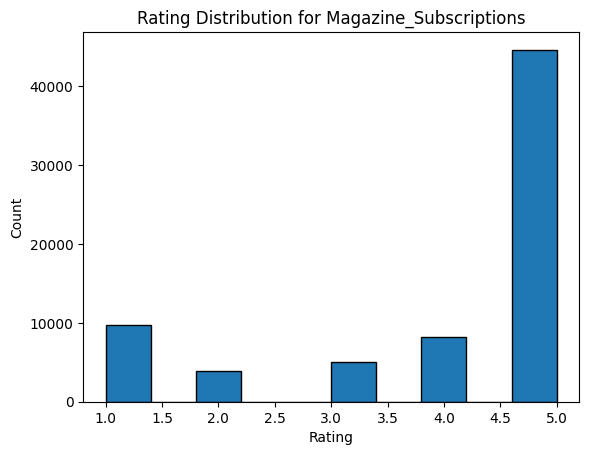

Subscription_Boxes.jsonl:   0%|          | 0.00/8.95M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

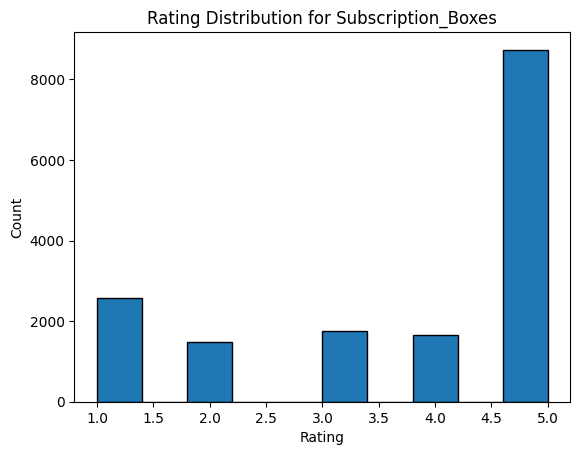

All_Beauty.jsonl:   0%|          | 0.00/327M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

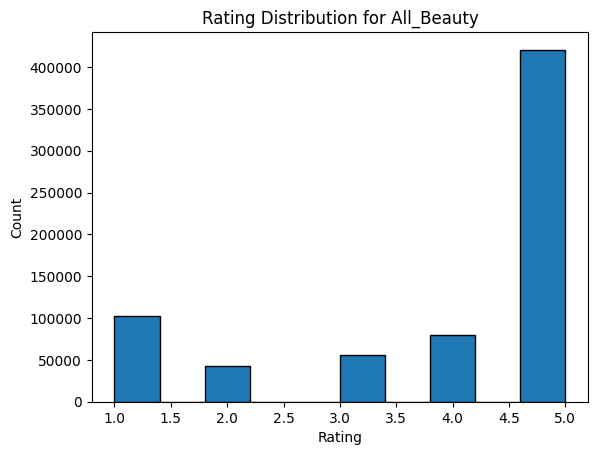

Digital_Music.jsonl:   0%|          | 0.00/78.8M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

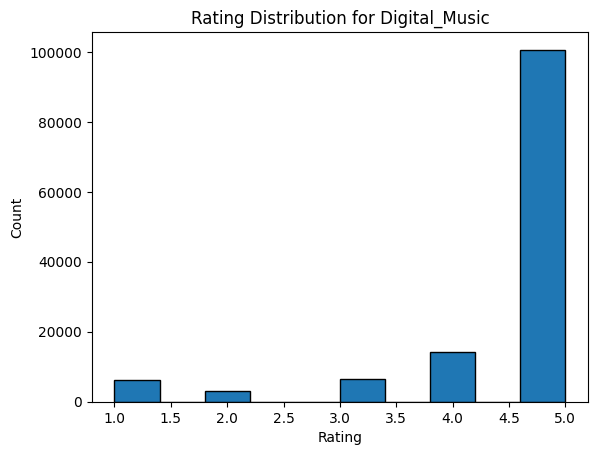

In [ ]:
from datasets import load_dataset
import json
import seaborn
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from collections import Counter
from wordcloud import WordCloud
from collections import defaultdict
from datetime import datetime
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import string



nltk.download('vader_lexicon')
nltk.download('stopwords')


#Part 1 - Task 1
categories = [
    "Gift_Cards",
    "Magazine_Subscriptions",
    "Subscription_Boxes",
    "All_Beauty",
    "Digital_Music"
    ]
#Ratings and Reviews

# What is the distribution of product ratings within each of the 5 selected
# categories?

average_rating = {}
reviews ={}

for cat in categories:
  reviews[cat] = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{cat}",trust_remote_code=True, split="full")
  ratings = reviews[cat]['rating']

  plt.figure()
  plt.hist(ratings, bins=10, edgecolor='black')
  plt.title(f'Rating Distribution for {cat}')
  plt.xlabel('Rating')
  plt.ylabel('Count')
  plt.show()

  average_rating[cat]=sum(ratings) / len(ratings)








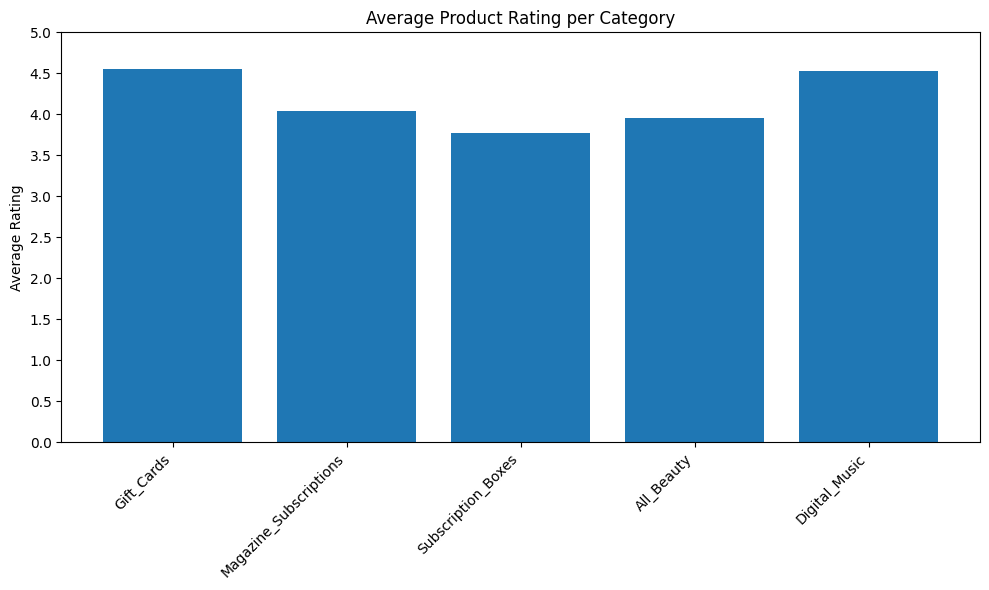

In [ ]:
# Are there any categories with significantly higher or lower
# average ratings?

# Answer: This is biggest diference between average ratings

#'Subscription_Boxes': 3.7701036013813516, 'Gift_Cards': 4.552804934059445}

plt.figure(figsize=(10,6))
plt.bar(average_rating.keys(), average_rating.values())
plt.ylabel('Average Rating')
plt.title('Average Product Rating per Category')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5)

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.5))

plt.tight_layout()
plt.show()

meta_Gift_Cards.jsonl:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

Generating full split:   0%|          | 0/1137 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1137 [00:00<?, ? examples/s]

Filter:   0%|          | 0/152410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/24162 [00:00<?, ? examples/s]

...

meta_Digital_Music.jsonl:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/70537 [00:00<?, ? examples/s]

Filter:   0%|          | 0/130434 [00:00<?, ? examples/s]

Filter:   0%|          | 0/29816 [00:00<?, ? examples/s]

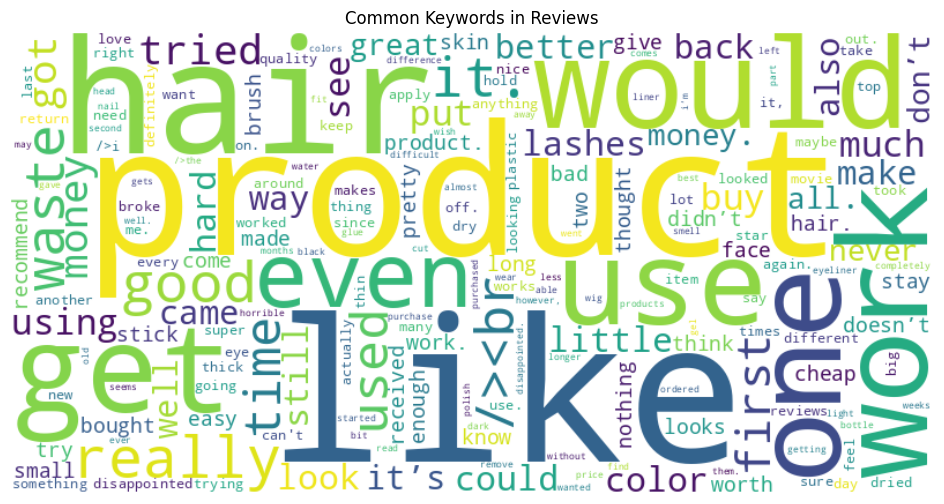

In [ ]:
# Identify products with a high number of reviews but low ratings. What are
# some common keywords or phrases in the reviews for these products?

metadata = {}
filtered_metadata = {}
joined_reviews = {}

stop_words = set(stopwords.words('english'))



for cat in categories:
  metadata[cat] = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{cat}",trust_remote_code=True, split="full")


  filtered_metadata[cat] = metadata[cat].filter(lambda x: (x.get("average_rating", 0) < average_rating[cat] - 0.5 ) and (x.get("rating_number", 0) > 50) )

  metadata_dict = {
    item["parent_asin"]: item
    for item in filtered_metadata[cat]
    if "parent_asin" in item
  }

  def join_with_metadata(review):
    asin = review.get("parent_asin")
    return metadata_dict.get(asin) is not None

  joined_reviews[cat] = reviews[cat].filter(lambda x: (x.get("rating", 0) < average_rating[cat] - 0.5)).select_columns(["text", "parent_asin", "rating"]).filter(join_with_metadata)


all_words = []
for cat in categories:
  for review in joined_reviews[cat]:
    text = review["text"].lower()
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words and len(w) > 2]
    all_words.extend(filtered_words)

word_counts = Counter(all_words)

common_keywords = word_counts.most_common(100)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Keywords in Reviews")
plt.show()

# for word, count in common_keywords:
#     print(word, count)




In [ ]:
#For each of the 5 selected categories, identify the top 5 best-selling
#(highest review count) products. What are their key attributes (features)?

best_selling_products = {}

for cat in categories:
  best_selling_products[cat] = metadata[cat].sort("rating_number", reverse=True).select(range(5))


for category, products in best_selling_products.items():
    print(f"\nTop 5 best-selling products in category: {category}")
    for i, product in enumerate(products, 1):
        print(f"\nProduct #{i}:")
        print(f"  Name: {product.get('title', 'N/A')}")
        print(f"  Rating: {product.get('rating_number', 'N/A')}")
        print(f"  Features:")

        features = product.get("features", {})
        for feature in features:
          print(f"    - {feature}")





Top 5 best-selling products in category: Gift_Cards

Product #1:
  Name: Amazon.com Gift Card in a Holiday Gift Box (Various Designs)
  Rating: 185606
  Features:
    - Gift Card is affixed inside a box
    - Gift amount may not be printed on Gift Cards
    - You can customize the gift amount as desired, for example $36, $54, $72, etc.
    - Gift Card has no fees and no expiration date
    - Gift Card is redeemable towards millions of items storewide at Amazon.com
    - Scan and redeem any Gift Card with a mobile or tablet device via the Amazon App
    - Free One-Day Shipping (where available)
    - Customized gift message, if chosen at check-out, only appears on packing slip and not on the actual gift card or carrier

Product #2:
  Name: Amazon Reload
  Rating: 143309
  Features:
    - Add funds to your Amazon Gift Card balance, then use your balance to manage how much you spend while shopping.
    - Save up for a purchase by adding funds to your Gift Card balance.
    - Checkout fas

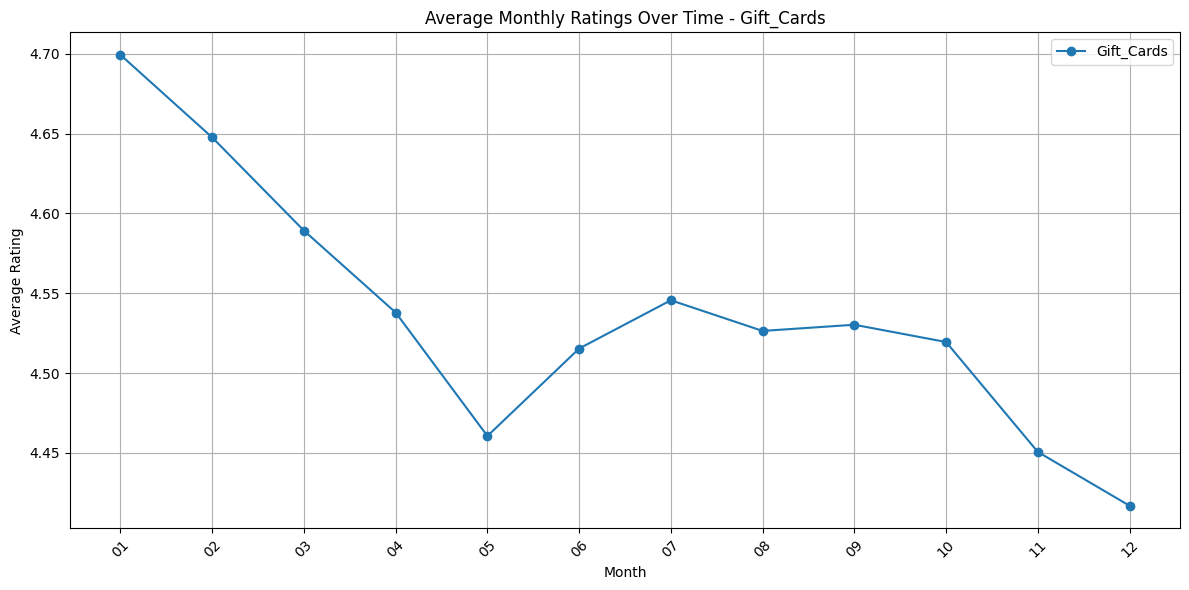

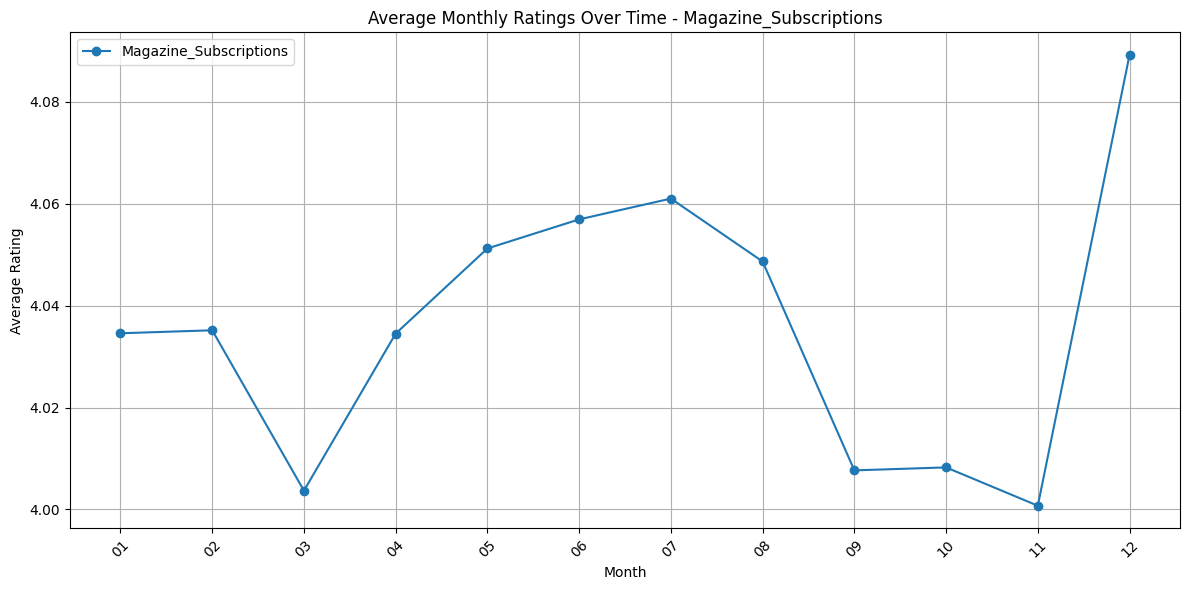

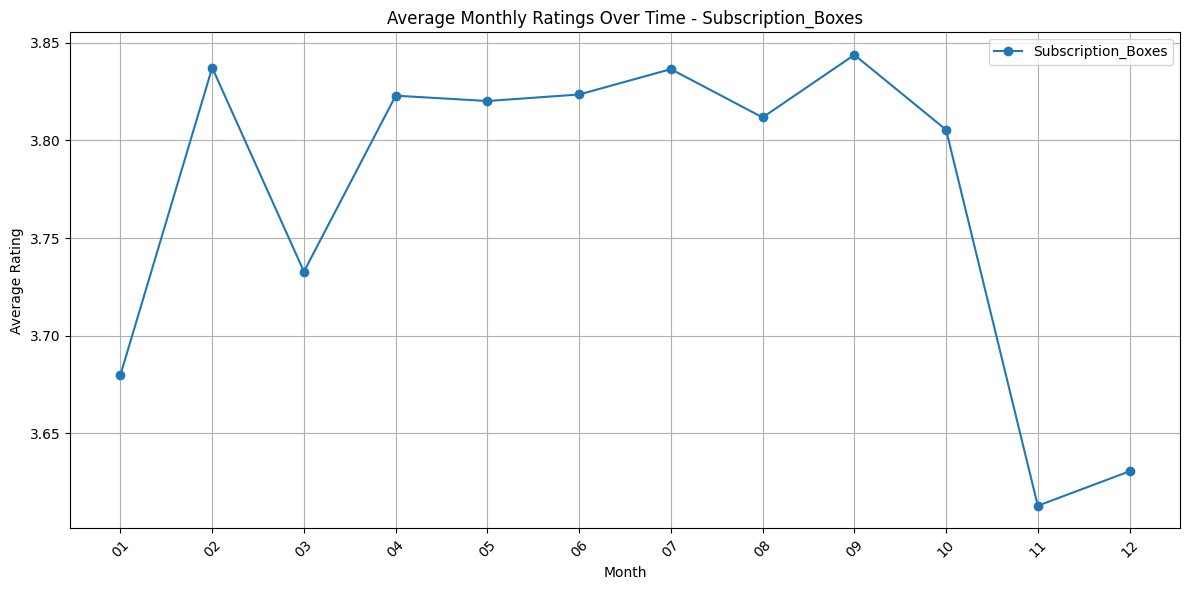

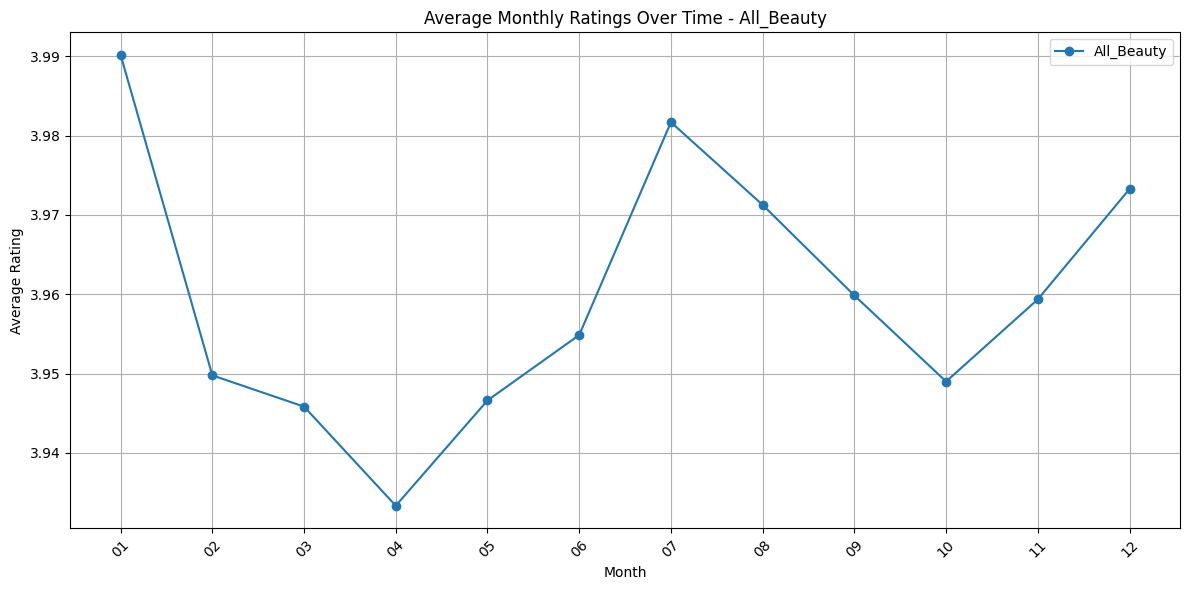

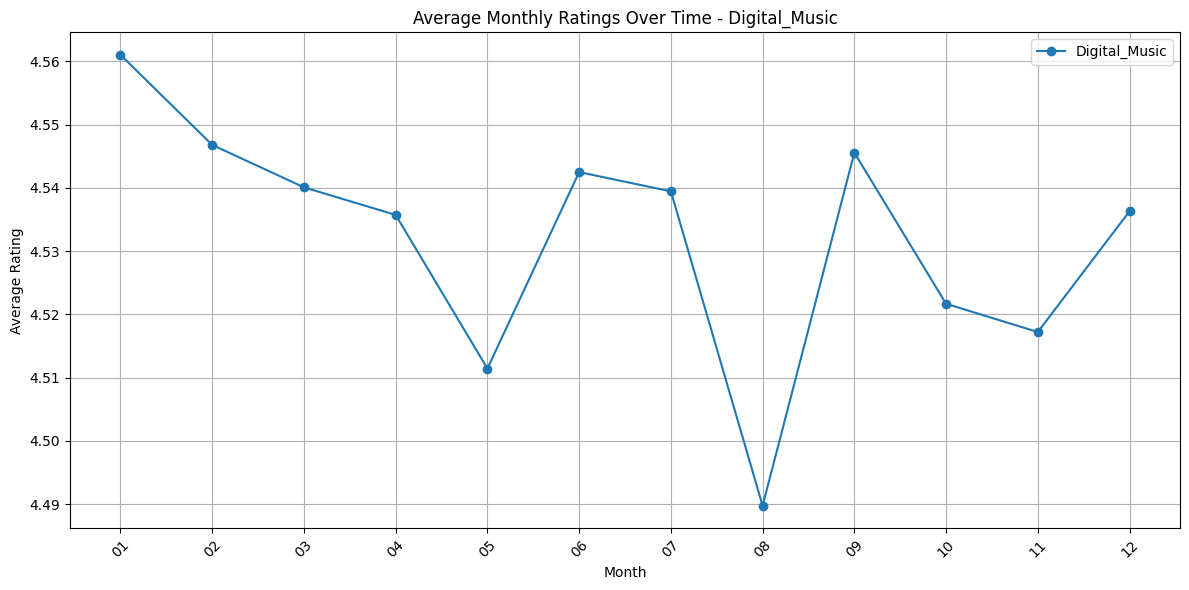

In [ ]:
# How have average product ratings evolved over time within each category?
# Create line plots to show the average rating “trend” for each category over
# months or years. Are there any noticeable patterns or seasonal variations?

category_monthly_averages = {}

for category in categories:
    monthly_ratings = defaultdict(list)

    for example in reviews[category]:
        rating = example.get("rating")
        date_str = example.get("timestamp")
        review_date = datetime.fromtimestamp(date_str/1000)
        month_str = review_date.strftime("%m")
        monthly_ratings[month_str].append(rating)

    average_monthly_ratings = {}

    for month, ratings in monthly_ratings.items():
        average = sum(ratings) / len(ratings)
        average_monthly_ratings[month] = average

    category_monthly_averages[category] = average_monthly_ratings




for category, averages in category_monthly_averages.items():
    plt.figure(figsize=(12, 6))

    sorted_months = sorted(averages.keys())
    average_ratings = [averages[month] for month in sorted_months]

    plt.plot(sorted_months, average_ratings, marker='o', label=category)
    plt.title(f"Average Monthly Ratings Over Time - {category}")
    plt.xlabel("Month")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



In [ ]:
#Part 1 - Task 2: Feature Engineering with Sentiment Scores and Ratings


#Alternative 1: Weighted Combination of Text Sentiment and Rating


w1 = 0.6
w2 = 0.4


vader = SentimentIntensityAnalyzer()

w1 = 0.6
w2 = 0.4


vader = SentimentIntensityAnalyzer()

def get_sentiment(review):
    text = review.get("text", "")
    rating = review.get("rating", None)

    if not text or rating is None:
        return {
            "vader_sentiment": None,
            "normalized_rating": None,
            "final_sentiment_score": None
        }

    vader_score = vader.polarity_scores(text)["compound"]
    normalized_rating = (rating - 1) / 4
    final_score = w1 * vader_score + w2 * normalized_rating

    return {
        "vader_sentiment": vader_score,
        "normalized_rating": normalized_rating,
        "final_sentiment_score": final_score
    }

for cat in categories:
  reviews[cat] = reviews[cat].map(get_sentiment)

# for cat in categories:
#   ds = reviews[cat]
#   print(f"\n=== Category: {cat} ===")
#   for example in ds.take(3):
#       print(f"• Text:   {example['text']}")
#       print(f"  Rating: {example['rating']}")
#       print(f"  vader_sentiment: {example['vader_sentiment']:.3f}")
#       print(f"  normalized_rating: {example['normalized_rating']:.3f}")
#       print(f"  final_sentiment_score: {example['final_sentiment_score']:.3f}")



Map:   0%|          | 0/152410 [00:00<?, ? examples/s]

Map:   0%|          | 0/71497 [00:00<?, ? examples/s]

Map:   0%|          | 0/16216 [00:00<?, ? examples/s]

Map:   0%|          | 0/701528 [00:00<?, ? examples/s]

Map:   0%|          | 0/130434 [00:00<?, ? examples/s]

**PART** **2**

In [ ]:
!pip install kneed

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Loading and preprocessing: Gift_Cards


meta_Gift_Cards.jsonl:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

Generating full split:   0%|          | 0/1137 [00:00<?, ? examples/s]

Map:   0%|          | 0/1137 [00:00<?, ? examples/s]

...


Loading and preprocessing: Digital_Music


meta_Digital_Music.jsonl:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/70537 [00:00<?, ? examples/s]


=== Elbow Method for category: Gift_Cards ===


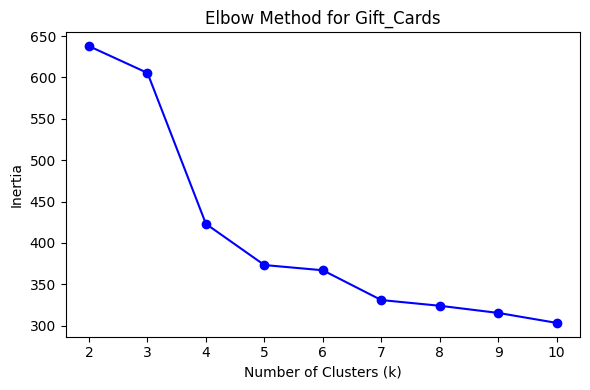

📌 Optimal k for Gift_Cards: 5

=== Elbow Method for category: Magazine_Subscriptions ===
[!] Skipping Magazine_Subscriptions — no valid data for Elbow Method.

=== Elbow Method for category: Subscription_Boxes ===
[!] Skipping Subscription_Boxes — no valid data for Elbow Method.

=== Elbow Method for category: All_Beauty ===


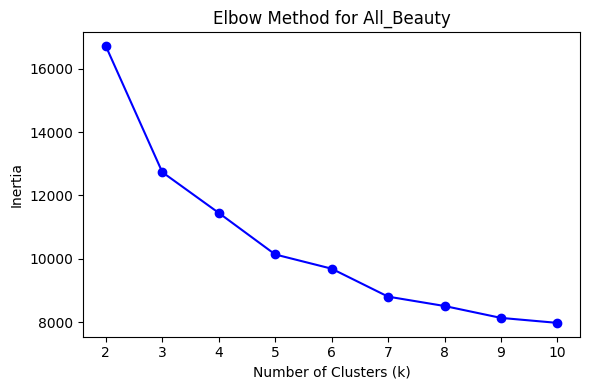

📌 Optimal k for All_Beauty: 5

=== Elbow Method for category: Digital_Music ===


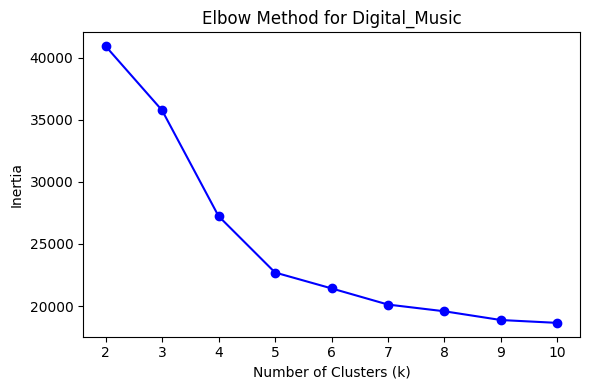

📌 Optimal k for Digital_Music: 5


In [ ]:
#part2 task 1
#elbow method to find k

import string
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from kneed import KneeLocator

nltk.download('stopwords')


stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


categories = ["Gift_Cards", "Magazine_Subscriptions", "Subscription_Boxes", "All_Beauty", "Digital_Music"]

def preprocess_text(item):
    text_list = item.get("description", [])
    if not text_list:
        item["preprocessed_description"] = ""
        return item

    text = " ".join(text_list).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    item["preprocessed_description"] = " ".join(tokens)
    return item

metadata = {}
metadata_for_clustering = {}
best_k_per_category = {}

for cat in categories:
    print(f"\nLoading and preprocessing: {cat}")
    metadata[cat] = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{cat}", trust_remote_code=True, split="full")
    metadata_for_clustering[cat] = metadata[cat].map(preprocess_text)

for cat in categories:
    print(f"\n=== Elbow Method for category: {cat} ===")
    dataset = metadata_for_clustering[cat]
    df = pd.DataFrame(dataset)

    #filter valid
    df = df[df["price"].notnull() & df["average_rating"].notnull()]
    df = df[df["preprocessed_description"].str.strip() != ""]

    df.loc[:, "price"] = pd.to_numeric(df["price"], errors="coerce")
    df.loc[:, "average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
    df = df.dropna(subset=["price", "average_rating"]).copy()

    if df.empty:
        print(f"[!] Skipping {cat} — no valid data for Elbow Method.")
        continue


    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[["price", "average_rating"]])

    tfidf = TfidfVectorizer(max_features=500)
    tfidf_matrix = tfidf.fit_transform(df["preprocessed_description"])

    from scipy.sparse import hstack
    X = hstack([tfidf_matrix, scaled_features])

    #k from 2 to 10
    inertias = []
    K_range = range(2, 11)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method for {cat}")
    plt.xticks(K_range)
    plt.tight_layout()
    plt.show()


    knee = KneeLocator(K_range, inertias, curve="convex", direction="decreasing")
    best_k = knee.knee or 5 #use 5 as default if we dont find using knee
    best_k_per_category[cat] = best_k

    print(f"Optimal k for {cat}: {best_k}")



#magazine subscriptions and subscription boxes are skipped both here and in the clustering (next block) due to missing or insufficient data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Map:   0%|          | 0/1137 [00:00<?, ? examples/s]

Map:   0%|          | 0/3391 [00:00<?, ? examples/s]

Map:   0%|          | 0/641 [00:00<?, ? examples/s]

Map:   0%|          | 0/112590 [00:00<?, ? examples/s]

Map:   0%|          | 0/70537 [00:00<?, ? examples/s]


=== Processing category: Gift_Cards ===
Silhouette Score for Gift_Cards: 0.156


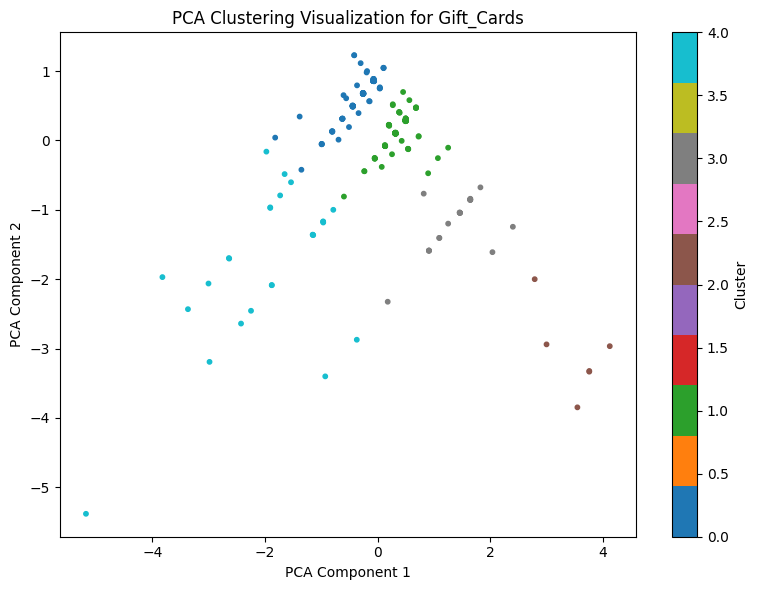


Cluster 0 Summary:
- Size: 123 products
- Avg Price: $24.51
- Avg Rating: 4.77
- Sample Titles: ['Amazon.com Gift Card in a Reveal (Various Designs)', 'Finish Line Gift Card', "Atria's Restaurant & Tavern Gift Card"]

Cluster 1 Summary:
- Size: 108 products
- Avg Price: $50.51
- Avg Rating: 4.82
- Sample Titles: ['Tractor Supply Company Gift Card', 'Staples Gift Card', 'Ninety Nine Restaurants Gift Card']

Cluster 2 Summary:
- Size: 6 products
- Avg Price: $188.66
- Avg Rating: 4.80
- Sample Titles: ['$200 Mastercard Gift Card (plus $6.95 Purchase Fee)', 'Apple Gift Card - App Store, iTunes, iPhone, iPad, AirPods, MacBook, accessories and more', 'Body Massage Wellness Spa - Denver, CO Gift Card']

Cluster 3 Summary:
- Size: 23 products
- Avg Price: $101.26
- Avg Rating: 4.73
- Sample Titles: ['Darden Restaurants Gift Box', 'Uber Gift Card', "Kohl's Gift Card"]

Cluster 4 Summary:
- Size: 26 products
- Avg Price: $41.55
- Avg Rating: 3.66
- Sample Titles: ['Happy Birthday Swap', 'Taco 

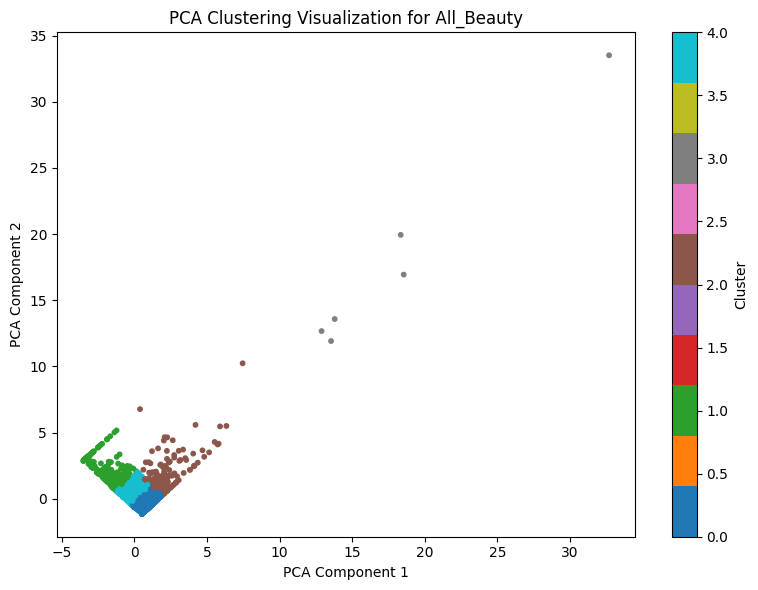


Cluster 0 Summary:
- Size: 3829 products
- Avg Price: $22.90
- Avg Rating: 4.63
- Sample Titles: ['BioMiracle StarDust Pixie Bubble Mask, Clarifying Foaming Face Mask with Green Tea and Apple, Carbonated Bubble Cupro Sheet Mask for Clear, Even Skin', 'Garnier Fructis Color Sealer, Instant, Lightweight Leave-In, Color Shield, For Color-Treated Hair, 6 oz.', 'Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)']

Cluster 1 Summary:
- Size: 625 products
- Avg Price: $20.94
- Avg Rating: 2.53
- Sample Titles: ['SERGE LUTENS PARFUMS La Fille De Berlin, Mini.03 oz', '110 Rose Gold Dots 1 mm Stick On Fake Nose Studs/Gold Fake Nose labret Eye Piercing Stud/Self Adhesive Nose Stud/Fake Nose Stud/Costume Jewels', 'Orly Neon Earth Collection Summer 2018 Nail Lacquer Sands of Time #20978"']

Cluster 2 Summary:
- Size: 147 products
- Avg Price: $186.00
- Avg Rating: 4.36
- Sample Titles: ['Wholesale CASE of 10 - GOJO Supro Max Cherry Hand Cleaner-Supro Max Hand Cleaner, 2000l,

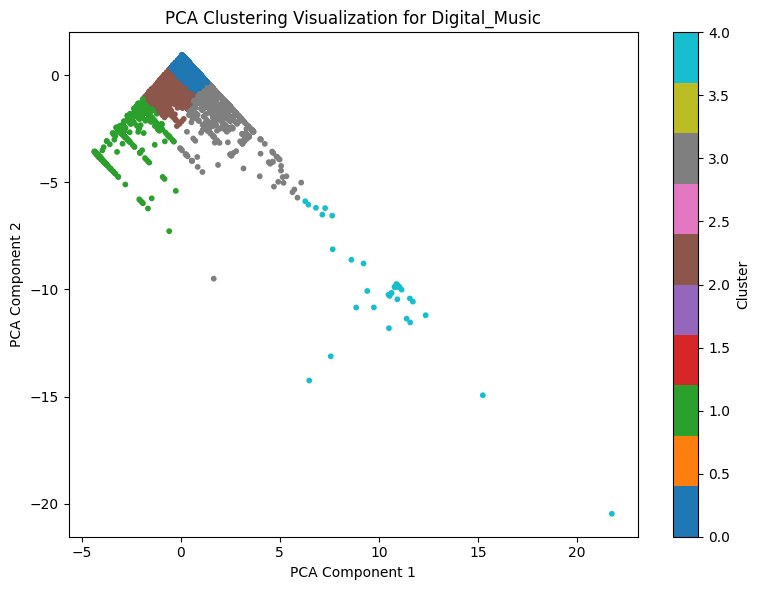


Cluster 0 Summary:
- Size: 11892 products
- Avg Price: $25.67
- Avg Rating: 4.83
- Sample Titles: ['TRIO +1', 'Indigo for Quantum Focus (Metamusic)', 'The Minimalism of Erik Satie']

Cluster 1 Summary:
- Size: 787 products
- Avg Price: $28.02
- Avg Rating: 2.35
- Sample Titles: ['Robert Preston: First Stereo Recordings of Rubinstein, Kabalevsky Piano Concertos', 'Avb: The Early Years', 'Allele']

Cluster 2 Summary:
- Size: 3429 products
- Avg Price: $26.94
- Avg Rating: 4.07
- Sample Titles: ['Initiation: Inside the Great Pyramid', 'Too Late Blues', 'Beethoven: Symphony No. 7 / Symphony No. 2']

Cluster 3 Summary:
- Size: 898 products
- Avg Price: $184.77
- Avg Rating: 4.72
- Sample Titles: ["Grateful Dead Dave's Picks Volume 25 Live at Broome County Veteran Memorial Arena Binghamton, NY November 6, 1977", 'Sir Thomas', "The Sons of the Pioneers, Greatest Hits, Collector's Edition"]

Cluster 4 Summary:
- Size: 35 products
- Avg Price: $884.41
- Avg Rating: 4.51
- Sample Titles: ['Heal

In [ ]:
#Part 2 - Task 1  Clustering for Product Grouping
#Group similar products within categories based on features like price, description, and
#ratings(average_rating).

import string
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
nltk.download('stopwords')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


def preprocess_text(item):
    text_list = item.get("description", [])
    if not text_list:
        item["preprocessed_description"] = ""
        return item

    text = " ".join(text_list).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    item["preprocessed_description"] = " ".join(tokens)
    return item



metadata = {}
for cat in categories:
    metadata[cat] = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{cat}", trust_remote_code=True, split="full")


metadata_for_clustering = {}
for cat in categories:
    metadata_for_clustering[cat] = metadata[cat].map(preprocess_text)



for cat in categories:
    print(f"\n=== Processing category: {cat} ===")

    dataset = metadata_for_clustering[cat]

    df = pd.DataFrame(dataset)

    df = df[df["price"].notnull() & df["average_rating"].notnull()]
    df = df[df["preprocessed_description"].str.len() > 0]

    #sometimes prices are strings
    df.loc[:, "price"] = pd.to_numeric(df["price"], errors="coerce")
    df.loc[:, "average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")

    df = df.dropna(subset=["price", "average_rating"]).copy()

    df = df[df["preprocessed_description"].str.strip() != ""]  # just in case

    if df.empty:
        print(f"[!] Skipping category {cat} — no valid data after filtering.")
        continue

    df = df.reset_index(drop=True)

    #scaling
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[["price", "average_rating"]])

    tfidf = TfidfVectorizer(max_features=500)  # limit vocab size
    tfidf_matrix = tfidf.fit_transform(df["preprocessed_description"])

    #combine TF IDF with scaled Numeric Features
    from scipy.sparse import hstack
    X = hstack([tfidf_matrix, scaled_features])


    k = best_k_per_category[cat]
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    df["cluster"] = labels


    score = silhouette_score(X, labels)
    print(f"Silhouette Score for {cat}: {score:.3f}")

    #visualize with PCA
    pca = PCA(n_components=2)
    X_dense = X.toarray()
    X_reduced = pca.fit_transform(X_dense)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap="tab10", s=10)
    plt.title(f"PCA Clustering Visualization for {cat}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(label="Cluster")
    plt.tight_layout()
    plt.show()

    for cluster_id in sorted(df["cluster"].unique()):
        group = df[df["cluster"] == cluster_id]
        print(f"\nCluster {cluster_id} Summary:")
        print(f"- Size: {len(group)} products")
        print(f"- Avg Price: ${group['price'].mean():.2f}")
        print(f"- Avg Rating: {group['average_rating'].mean():.2f}")
        print(f"- Sample Titles: {group['title'].head(3).tolist()}")






In [ ]:
!wget -c "https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M-subword.vec.zip"
!unzip -q wiki-news-300d-1M-subword.vec.zip


--2025-06-22 07:00:21--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M-subword.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.173.132.13, 18.173.132.81, 18.173.132.6, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.173.132.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 587879973 (561M) [application/zip]
Saving to: ‘wiki-news-300d-1M-subword.vec.zip’

wiki-news-300d-1M-s 100%[===================>] 560.65M  96.0MB/s    in 7.8s    

2025-06-22 07:00:28 (71.5 MB/s) - ‘wiki-news-300d-1M-subword.vec.zip’ saved [587879973/587879973]



In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 13.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

In [ ]:
#Task3:  Classification task - sentiment analysis

import re
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes    import MultinomialNB
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.metrics        import precision_recall_fscore_support, accuracy_score
from tabulate               import tabulate
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection       import StratifiedKFold, cross_validate
import nltk
from gensim.models import KeyedVectors



nltk.download('punkt_tab')

ds = reviews['Magazine_Subscriptions']
ds = ds.filter(lambda ex: ex["final_sentiment_score"] is not None)

split = ds.train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]
test_ds  = split["test"]

def preprocess(batch):
    cleaned_texts = []
    for txt in batch["text"]:
        txt = txt.lower()
        txt = re.sub(r"<.*?>", "", txt)
        txt = re.sub(r"http\S+|www\.\S+", "", txt)
        txt = re.sub(r"[^a-z0-9\s]", " ", txt)
        tokens = word_tokenize(txt)
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
        clean_txt = " ".join(tokens)
        cleaned_texts.append(clean_txt)
    return {"clean_text": cleaned_texts}

train_ds = train_ds.map(preprocess, batched=True)
test_ds  = test_ds.map(preprocess,  batched=True)

#final_sentiment to discrete values
def discrete_sentiment(score, neg_thresh=-0.1, pos_thresh=0.1):
  if score <= neg_thresh:
      return 0
  elif score >= pos_thresh:
      return 2
  else:
      return 1

def map_to_label(batch):
    return {
        "discrete_sentiment_score": [discrete_sentiment(s) for s in batch["final_sentiment_score"]]
    }

train_ds = train_ds.map(map_to_label, batched=True)
test_ds  = test_ds.map(map_to_label,  batched=True)


tfidf = TfidfVectorizer(max_features=5_000)
X_tfidf_train = tfidf.fit_transform(train_ds["clean_text"]) #sparse
X_tfidf_test  = tfidf.transform(test_ds["clean_text"])

ft_path = "/content/wiki-news-300d-1M-subword.vec"
ft = KeyedVectors.load_word2vec_format(ft_path)

def embed_reviews_fasttext(texts):
    embs = []
    for doc in texts:
        tokens = word_tokenize(doc)
        vecs = [ft[w] for w in tokens if w in ft.key_to_index]
        if vecs:
            embs.append(np.mean(vecs, axis=0))
        else:
            embs.append(np.zeros(ft.vector_size))
    return np.vstack(embs)

X_ft_train = embed_reviews_fasttext(train_ds["clean_text"]) #dense
X_ft_test  = embed_reviews_fasttext(test_ds["clean_text"])


y_train = np.array(train_ds["discrete_sentiment_score"])
y_test  = np.array(test_ds["discrete_sentiment_score"])


models = {
    "Gaussian NB":   GaussianNB(), #needs dense
    "KNN":           KNeighborsClassifier(n_neighbors=5), #pretty much needs dense
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42), #both
}

feature_sets = {
    "TF-IDF":   (X_tfidf_train, X_tfidf_test),
    "FastText": (X_ft_train,    X_ft_test),
}

scoring = ["precision_macro", "recall_macro", "f1_macro", "accuracy"]


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []


for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        X_input = X_tr
        if (hasattr(X_input, "toarray") and  model_name in ("Gaussian NB", "KNN")):
            X_input = X_input.toarray()

        scores = cross_validate(
            model,
            X_input,
            y_train,
            cv=cv,
            scoring=scoring,
            error_score="raise"
        )

        cv_results.append({
            "Feature Set": feat_name,
            "Model":       model_name,
            "Precision":   scores["test_precision_macro"].mean(),
            "Recall":      scores["test_recall_macro"].mean(),
            "F1-Score":    scores["test_f1_macro"].mean(),
            "Accuracy":    scores["test_accuracy"].mean()
        })


print("\n 10-Fold CV Results (train set) ")
print(tabulate(
    [[r["Feature Set"], r["Model"],
      f"{r['Precision']:.3f}", f"{r['Recall']:.3f}",
      f"{r['F1-Score']:.3f}", f"{r['Accuracy']:.3f}"]
     for r in cv_results],
    headers=["Feature Set","Model","Precision","Recall","F1-Score","Accuracy"],
    tablefmt="github"
))




 10-Fold CV Results (train set) 
| Feature Set   | Model         |   Precision |   Recall |   F1-Score |   Accuracy |
|---------------|---------------|-------------|----------|------------|------------|
| TF-IDF        | Gaussian NB   |       0.377 |    0.43  |      0.245 |      0.31  |
| TF-IDF        | KNN           |       0.646 |    0.401 |      0.428 |      0.882 |
| TF-IDF        | Random Forest |       0.738 |    0.457 |      0.507 |      0.895 |
| FastText      | Gaussian NB   |       0.418 |    0.501 |      0.315 |      0.401 |
| FastText      | KNN           |       0.586 |    0.434 |      0.467 |      0.879 |
| FastText      | Random Forest |       0.768 |    0.391 |      0.418 |      0.886 |


In [ ]:
# Based on the above results:
# Train the best (based on F1) on the whole train dataset, evaluate on test dataset

best_feats = {}
for entry in cv_results:
    model = entry["Model"]
    f1    = entry["F1-Score"]
    feat  = entry["Feature Set"]
    if model not in best_feats or f1 > best_feats[model][0]:
        best_feats[model] = (f1, feat)

best_feats = {m: feat for m, (_, feat) in best_feats.items()}


test_results = []
for model_name, model in models.items():
    feat_name = best_feats[model_name]
    X_tr, X_te = feature_sets[feat_name]

    if hasattr(X_tr, "toarray") and model_name in ("Gaussian NB", "KNN"):
        X_tr = X_tr.toarray()
        X_te = X_te.toarray()

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    acc = accuracy_score(y_test, y_pred)
    test_results.append({
        "Model":       model_name,
        "Feature Set": feat_name,
        "Precision":   p,
        "Recall":      r,
        "F1-Score":    f1,
        "Accuracy":    acc
    })

rows = []
for rec in test_results:
    model = rec["Model"]
    feat  = rec["Feature Set"]
    cv_f1 = next(
        (e["F1-Score"] for e in cv_results
         if e["Model"] == model and e["Feature Set"] == feat),
        None
    )
    rows.append([
        model,
        feat,
        f"{cv_f1:.3f}",
        f"{rec['F1-Score']:.3f}",
        f"{rec['Precision']:.3f}",
        f"{rec['Recall']:.3f}",
        f"{rec['Accuracy']:.3f}",
    ])


print("\nFinal Test Evaluation vs. CV F1\n")
print(tabulate(
    rows,
    headers=["Model","Feature","CV F1","Test F1","Precision","Recall","Accuracy"],
    tablefmt="github"
))



Final Test Evaluation vs. CV F1

| Model         | Feature   |   CV F1 |   Test F1 |   Precision |   Recall |   Accuracy |
|---------------|-----------|---------|-----------|-------------|----------|------------|
| Gaussian NB   | FastText  |   0.315 |     0.318 |       0.418 |    0.499 |      0.408 |
| KNN           | FastText  |   0.467 |     0.478 |       0.59  |    0.444 |      0.879 |
| Random Forest | TF-IDF    |   0.507 |     0.518 |       0.732 |    0.465 |      0.895 |
